# Compare Multiple DPLM Runs by EnzymeExplorer isTPS Metrics

This notebook loads multiple DPLM training runs, extracts EnzymeExplorer `isTPS` scores for each step, and summarizes the best-performing steps by mean and median isTPS. Tables and plots are generated for easy comparison.

**Instructions:**
- In the next cell, edit the list of `train.log` paths for the runs you want to compare.
- All downstream analysis will be performed automatically for each run.

In [1]:
# --- 1. Define Run Inputs and Output Paths ---
from pathlib import Path

# User: Edit this dictionary to include all runs you want to compare
# Keys are run labels, values are absolute paths to train.log files
run_logs = {
    "run_41 V": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_41_lr1em3_wu2000_ts200000_ckpt10000_valee10000_lend0p0001_winit1em06_loratrue_ns50_r1_a2_ltmV/train.log",
    "run_41 V (rerun)": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_41_LN_lr1em3_wu2000_ts200000_ckpt10000_valee10000_lend0p0001_winit1em06_loratrue_ns50_r1_a2_ltmV_no_LN_4276685/train.log",
    "run_41 V+LN": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_41_LN_lr1em4_wu2000_ts200000_ckpt10000_valee10000_lend1em5_winit1em7_loratrue_ns50_r1_a2_ltmV/train.log",
}

# Output directory for combined results
output_dir = Path("/Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")
print(f"Runs loaded: {list(run_logs.keys())}")

Output directory: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison
Runs loaded: ['run_41 V', 'run_41 V (rerun)', 'run_41 V+LN']


In [2]:
# Switch: If True, use last checkpoint for each run instead of best (median/mean)
USE_LAST_CHECKPOINT = False  # <-- Set to True to use last checkpoint

# Switch: If True, ALSO emit a *_sorted.png of the bar chart in which each
# subplot (median, mean) is sorted by its own score from best to worst.
# Colors stay consistent per run across both subplots — i.e. the same run
# keeps its color even when it lands in different x-positions on the two
# subplots. The unsorted figure is still written when the flag is True.
SORT_BY_PERFORMANCE = False  # <-- Set to True to also produce sorted plots


In [3]:
# --- 2. Import Libraries and Shared Parsing Utilities ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Utility: Robust isTPS column name matching
TARGET_COLUMN_NAME = "isTPS"
def find_isTPS_column(columns):
    # Accepts trailing spaces and case-insensitive
    for col in columns:
        if col.strip().lower() == TARGET_COLUMN_NAME.lower():
            return col
    return None

# Utility: Identify step folders (step_N, sanity_check_step_0)
def get_step_folders(enzyme_explorer_path):
    folders = []
    if not enzyme_explorer_path.exists():
        return folders
    # Add sanity_check_step_0 if present
    sanity = enzyme_explorer_path / "sanity_check_step_0"
    if sanity.exists() and sanity.is_dir():
        folders.append(sanity)
    # Add all step_N folders
    folders += sorted([
        f for f in enzyme_explorer_path.iterdir()
        if f.is_dir() and f.name.startswith("step_") and f.name.split("_")[-1].isdigit()
    ], key=lambda f: int(f.name.split("_")[-1]))
    return folders

In [4]:
# --- 3. Collect EnzymeExplorer isTPS Values per Step for Each Run ---
all_rows = []
for run_name, log_path in run_logs.items():
    log_path = Path(log_path)
    enzyme_explorer_path = log_path.parent / "enzyme_explorer_validation"
    step_folders = get_step_folders(enzyme_explorer_path)
    for step_folder in step_folders:
        step_name = step_folder.name
        # Extract numeric step index for sorting (sanity_check_step_0 = 0)
        if step_name.startswith("sanity_check_step_0"):
            step_index = 0
        else:
            try:
                step_index = int(step_name.split("_")[-1])
            except Exception:
                step_index = np.nan
        # Aggregate all CSVs in this step folder
        csv_files = list(step_folder.glob("*.csv"))
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
            except Exception as e:
                print(f"Error reading {csv_file}: {e}")
                continue
            col = find_isTPS_column(df.columns)
            if col is None:
                print(f"No isTPS column in {csv_file}")
                continue
            values = pd.to_numeric(df[col], errors="coerce").dropna()
            for v in values:
                all_rows.append({
                    "run_name": run_name,
                    "step_name": step_name,
                    "step_index": step_index,
                    "isTPS": v
                })

# Build long-form DataFrame
all_isTPS_df = pd.DataFrame(all_rows)
print(f"Loaded {len(all_isTPS_df)} isTPS values from all runs.")
display(all_isTPS_df.head())

Loaded 3150 isTPS values from all runs.


,run_name,step_name,step_index,isTPS
0,run_41 V,sanity_check_step_0,0,0.004782
1,run_41 V,sanity_check_step_0,0,0.186452
2,run_41 V,sanity_check_step_0,0,0.371945
3,run_41 V,sanity_check_step_0,0,0.356322
4,run_41 V,sanity_check_step_0,0,0.241077


In [5]:
# --- 4. Compute Step-Level Mean and Median isTPS per Run ---
if not all_isTPS_df.empty:
    step_stats = (
        all_isTPS_df
        .groupby(["run_name", "step_name", "step_index"], as_index=False)
        .agg(n_sequences=("isTPS", "count"), mean_isTPS=("isTPS", "mean"), median_isTPS=("isTPS", "median"))
        .sort_values(["run_name", "step_index"])
    )
    display(step_stats.head(10))
else:
    print("No isTPS values found in any run.")

,run_name,step_name,step_index,n_sequences,mean_isTPS,median_isTPS
0,run_41 V,sanity_check_step_0,0,50,0.259169,0.356836
1,run_41 V,step_10000,10000,50,0.750329,0.802616
12,run_41 V,step_20000,20000,50,0.714040,0.813205
14,run_41 V,step_30000,30000,50,0.808583,0.830041
15,run_41 V,step_40000,40000,50,0.813030,0.830027
16,run_41 V,step_50000,50000,50,0.759593,0.799359
17,run_41 V,step_60000,60000,50,0.811415,0.826625
18,run_41 V,step_70000,70000,50,0.832519,0.828685
19,run_41 V,step_80000,80000,50,0.821229,0.824363
20,run_41 V,step_90000,90000,50,0.784403,0.807341


In [6]:
# --- 5. Select Best Step by Median and Best Step by Mean, or Last Step ---
if not all_isTPS_df.empty:
    run_order = list(run_logs.keys())
    if USE_LAST_CHECKPOINT:
        # For each run, select the last step (highest step_index)
        last_steps = step_stats.loc[step_stats.groupby("run_name")['step_index'].idxmax()]
        # Preserve user order
        last_steps["run_name"] = pd.Categorical(last_steps["run_name"], categories=run_order, ordered=True)
        last_steps = last_steps.sort_values("run_name")
        summary = last_steps.rename(columns={
            "step_name": "last_step",
            "median_isTPS": "last_median_score",
            "mean_isTPS": "last_mean_score",
            "n_sequences": "n_sequences_at_last"
        })
        summary["run_name"] = pd.Categorical(summary["run_name"], categories=run_order, ordered=True)
        summary = summary.sort_values("run_name")
        display(summary)
    else:
        best_by_median = (
            step_stats.loc[step_stats.groupby("run_name")["median_isTPS"].idxmax()]
            .rename(columns={"step_name": "best_median_step", "median_isTPS": "best_median_score", "n_sequences": "n_sequences_at_best_median"})
        )
        best_by_mean = (
            step_stats.loc[step_stats.groupby("run_name")["mean_isTPS"].idxmax()]
            .rename(columns={"step_name": "best_mean_step", "mean_isTPS": "best_mean_score", "n_sequences": "n_sequences_at_best_mean"})
        )
        # Merge for summary
        summary = pd.merge(
            
best_by_median[["run_name", "best_median_score", "best_median_step", "n_sequences_at_best_median"]],
            
best_by_mean[["run_name", "best_mean_score", "best_mean_step", "n_sequences_at_best_mean"]],
            on="run_name",
            how="outer"
        )
        summary["run_name"] = pd.Categorical(summary["run_name"], categories=run_order, ordered=True)
        summary = summary.sort_values("run_name")
        display(summary)
else:
    print("No isTPS values found in any run.")

,run_name,best_median_score,best_median_step,n_sequences_at_best_median,best_mean_score,best_mean_step,n_sequences_at_best_mean
0,run_41 V,0.831062,step_120000,50,0.832519,step_70000,50
1,run_41 V (rerun),0.844580,step_140000,50,0.829578,step_190000,50
2,run_41 V+LN,0.870440,step_150000,50,0.870612,step_150000,50


In [7]:
# --- 6. Build Summary DataFrames for All Runs ---
if not all_isTPS_df.empty:
    run_order = list(run_logs.keys())
    if USE_LAST_CHECKPOINT:
        score_table = summary[["run_name", "last_median_score", "last_mean_score"]].copy()
        score_table["run_name"] = pd.Categorical(score_table["run_name"], categories=run_order, ordered=True)
        score_table = score_table.sort_values("run_name")
        score_table.to_csv(output_dir / "last_scores_summary.csv", index=False)
        print(f"Saved: {output_dir / 'last_scores_summary.csv'}")
        display(score_table)

        step_table = summary[["run_name", "last_step", "n_sequences_at_last"]].copy()
        step_table["run_name"] = pd.Categorical(step_table["run_name"], categories=run_order, ordered=True)
        step_table = step_table.sort_values("run_name")
        step_table.to_csv(output_dir / "last_steps_summary.csv", index=False)
        print(f"Saved: {output_dir / 'last_steps_summary.csv'}")
        display(step_table)
    else:
        score_table = summary[["run_name", "best_median_score", "best_mean_score"]].copy()
        score_table["run_name"] = pd.Categorical(score_table["run_name"], categories=run_order, ordered=True)
        score_table = score_table.sort_values("run_name")
        score_table.to_csv(output_dir / "best_scores_summary.csv", index=False)
        print(f"Saved: {output_dir / 'best_scores_summary.csv'}")
        display(score_table)

        step_table = summary[[
            "run_name", "best_median_step", "n_sequences_at_best_median", "best_mean_step", "n_sequences_at_best_mean"
        ]].copy()
        step_table["run_name"] = pd.Categorical(step_table["run_name"], categories=run_order, ordered=True)
        step_table = step_table.sort_values("run_name")
        step_table.to_csv(output_dir / "best_steps_summary.csv", index=False)
        print(f"Saved: {output_dir / 'best_steps_summary.csv'}")
        display(step_table)
else:
    print("No summary tables to display.")

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/best_scores_summary.csv


,run_name,best_median_score,best_mean_score
0,run_41 V,0.831062,0.832519
1,run_41 V (rerun),0.844580,0.829578
2,run_41 V+LN,0.870440,0.870612


Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/best_steps_summary.csv


,run_name,best_median_step,n_sequences_at_best_median,best_mean_step,n_sequences_at_best_mean
0,run_41 V,step_120000,50,step_70000,50
1,run_41 V (rerun),step_140000,50,step_190000,50
2,run_41 V+LN,step_150000,50,step_150000,50


Saved table figure: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/best_scores_summary.png


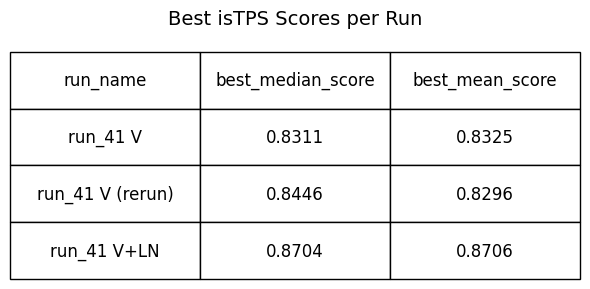

Saved table figure: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/best_steps_summary.png


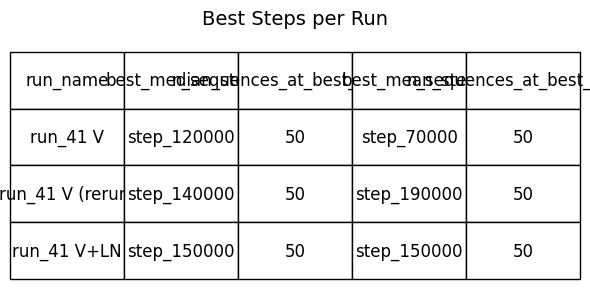

In [8]:
# --- 7. Render and Save Summary Tables as Figures and CSV ---
def render_table_as_figure(df, title, filename):
    fig, ax = plt.subplots(figsize=(max(6, len(df) * 1.5), 1.5 + 0.5 * len(df)))
    ax.axis('off')
    tbl = ax.table(
        cellText=df.round(4).values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center',
        colLoc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200, bbox_inches='tight')
    print(f"Saved table figure: {output_dir / filename}")
    plt.show()

if not all_isTPS_df.empty:
    render_table_as_figure(score_table, "Best isTPS Scores per Run", "best_scores_summary.png")
    render_table_as_figure(step_table, "Best Steps per Run", "best_steps_summary.png")

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/best_mean_median_separate_grouped_column_graphs.png


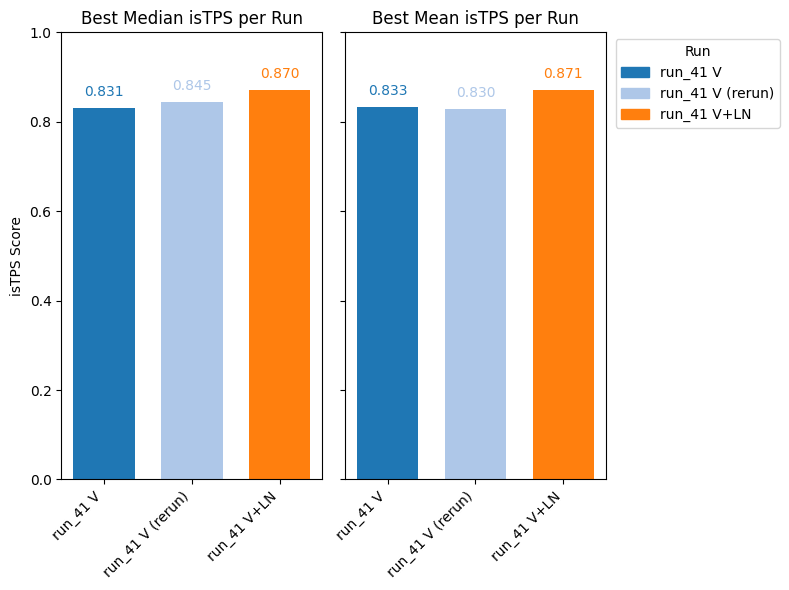

In [9]:
# --- 8. Plot Best Median and Best Mean Scores per Run as Separate Grouped Column Graphs ---

if not all_isTPS_df.empty:
    run_order = list(run_logs.keys())
    if USE_LAST_CHECKPOINT:
        labels = list(summary['run_name'])
        last_median = list(summary['last_median_score'])
        last_mean = list(summary['last_mean_score'])

        # Ensure labels are in user order
        labels = [label for label in run_order if label in labels]
        last_median = [summary.loc[summary['run_name'] == label, 'last_median_score'].values[0] for label in labels]
        last_mean = [summary.loc[summary['run_name'] == label, 'last_mean_score'].values[0] for label in labels]

        fig, axes = plt.subplots(1, 2, figsize=(max(8, len(labels) * 1.2), 6), sharey=True)
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % 20) for i in range(len(labels))]
        x = np.arange(len(labels))
        width = 0.7

        # Median plot
        ax = axes[0]
        ax.bar(x, last_median, width, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel('isTPS Score')
        ax.set_title('Last Median isTPS per Run')
        for idx in range(len(labels)):
            ax.text(x[idx], last_median[idx] + 0.02, f'{last_median[idx]:.3f}', ha='center', va='bottom', fontsize=10, color=colors[idx])

        # Mean plot
        ax = axes[1]
        ax.bar(x, last_mean, width, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylim(0.0, 1.0)
        ax.set_title('Last Mean isTPS per Run')
        for idx in range(len(labels)):
            ax.text(x[idx], last_mean[idx] + 0.02, f'{last_mean[idx]:.3f}', ha='center', va='bottom', fontsize=10, color=colors[idx])

        # Legend
        handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(labels))]
        axes[1].legend(handles, labels, title='Run', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        outpath = output_dir / "last_mean_median_separate_grouped_column_graphs.png"
        plt.savefig(outpath, dpi=200, bbox_inches="tight")
        print(f"Saved: {outpath}")
        plt.show()
    else:
        labels = list(summary['run_name'])
        best_median = list(summary['best_median_score'])
        best_mean = list(summary['best_mean_score'])

        # Ensure labels are in user order
        labels = [label for label in run_order if label in labels]
        best_median = [summary.loc[summary['run_name'] == label, 'best_median_score'].values[0] for label in labels]
        best_mean = [summary.loc[summary['run_name'] == label, 'best_mean_score'].values[0] for label in labels]

        fig, axes = plt.subplots(1, 2, figsize=(max(8, len(labels) * 1.2), 6), sharey=True)
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % 20) for i in range(len(labels))]
        x = np.arange(len(labels))
        width = 0.7

        # Median plot
        ax = axes[0]
        ax.bar(x, best_median, width, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel('isTPS Score')
        ax.set_title('Best Median isTPS per Run')
        for idx in range(len(labels)):
            ax.text(x[idx], best_median[idx] + 0.02, f'{best_median[idx]:.3f}', ha='center', va='bottom', fontsize=10, color=colors[idx])

        # Mean plot
        ax = axes[1]
        ax.bar(x, best_mean, width, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylim(0.0, 1.0)
        ax.set_title('Best Mean isTPS per Run')
        for idx in range(len(labels)):
            ax.text(x[idx], best_mean[idx] + 0.02, f'{best_mean[idx]:.3f}', ha='center', va='bottom', fontsize=10, color=colors[idx])

        # Legend
        handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(labels))]
        axes[1].legend(handles, labels, title='Run', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        outpath = output_dir / "best_mean_median_separate_grouped_column_graphs.png"
        plt.savefig(outpath, dpi=200, bbox_inches="tight")
        print(f"Saved: {outpath}")
        plt.show()

# --- 8b. Optional sorted-by-performance variant ---
# Same data, same colors (stable run -> color mapping), but each subplot is
# independently re-ordered from best to worst by its own metric.
if not all_isTPS_df.empty and SORT_BY_PERFORMANCE:
    run_order_local = list(run_logs.keys())
    if USE_LAST_CHECKPOINT:
        median_key, mean_key = "last_median_score", "last_mean_score"
        title_med = "Last Median isTPS per Run (sorted)"
        title_mean = "Last Mean isTPS per Run (sorted)"
        out_basename = "last_mean_median_separate_grouped_column_graphs_sorted.png"
    else:
        median_key, mean_key = "best_median_score", "best_mean_score"
        title_med = "Best Median isTPS per Run (sorted)"
        title_mean = "Best Mean isTPS per Run (sorted)"
        out_basename = "best_mean_median_separate_grouped_column_graphs_sorted.png"

    present_labels = [l for l in run_order_local if l in set(summary["run_name"])]

    cmap = plt.get_cmap('tab20')
    color_map = {label: cmap(i % 20) for i, label in enumerate(run_order_local)}

    def _sorted_pairs(metric_col):
        pairs = [
            (label, float(summary.loc[summary["run_name"] == label, metric_col].values[0]))
            for label in present_labels
        ]
        return sorted(pairs, key=lambda p: p[1], reverse=True)

    med_pairs = _sorted_pairs(median_key)
    mean_pairs = _sorted_pairs(mean_key)

    n = len(present_labels)
    fig, axes = plt.subplots(1, 2, figsize=(max(8, n * 1.2), 6), sharey=True)
    width = 0.7

    # Median (sorted by median score)
    ax = axes[0]
    med_labels = [p[0] for p in med_pairs]
    med_values = [p[1] for p in med_pairs]
    med_colors = [color_map[l] for l in med_labels]
    x = np.arange(n)
    ax.bar(x, med_values, width, color=med_colors)
    ax.set_xticks(x)
    ax.set_xticklabels(med_labels, rotation=45, ha='right')
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('isTPS Score')
    ax.set_title(title_med)
    for idx in range(n):
        ax.text(x[idx], med_values[idx] + 0.02, f'{med_values[idx]:.3f}',
                ha='center', va='bottom', fontsize=10, color=med_colors[idx])

    # Mean (sorted by mean score)
    ax = axes[1]
    mean_labels = [p[0] for p in mean_pairs]
    mean_values = [p[1] for p in mean_pairs]
    mean_colors = [color_map[l] for l in mean_labels]
    ax.bar(x, mean_values, width, color=mean_colors)
    ax.set_xticks(x)
    ax.set_xticklabels(mean_labels, rotation=45, ha='right')
    ax.set_ylim(0.0, 1.0)
    ax.set_title(title_mean)
    for idx in range(n):
        ax.text(x[idx], mean_values[idx] + 0.02, f'{mean_values[idx]:.3f}',
                ha='center', va='bottom', fontsize=10, color=mean_colors[idx])

    # Legend in run_order_local order (stable mapping; not the sorted order)
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[l]) for l in present_labels]
    axes[1].legend(handles, present_labels, title='Run',
                   bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    outpath = output_dir / out_basename
    plt.savefig(outpath, dpi=200, bbox_inches="tight")
    print(f"Saved: {outpath}")
    plt.show()


Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/run_41 V_isTPS_by_step.png


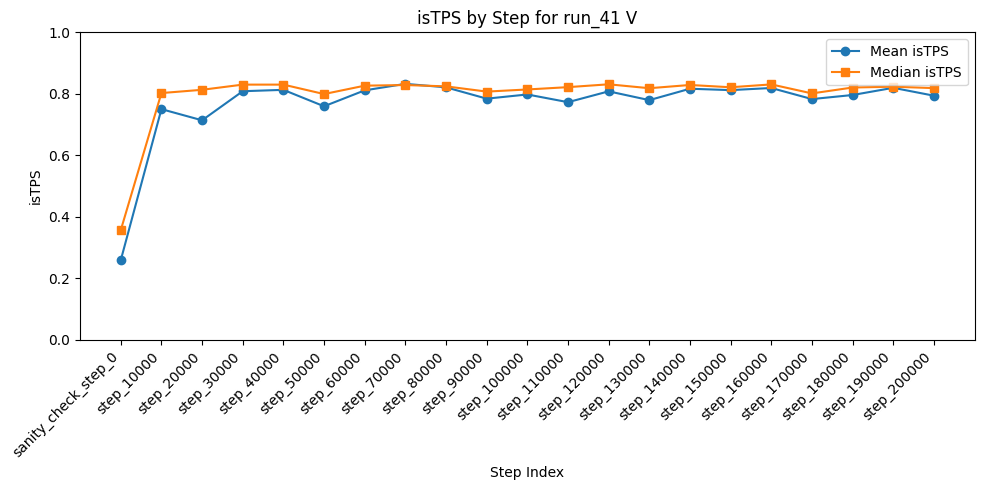

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/run_41 V (rerun)_isTPS_by_step.png


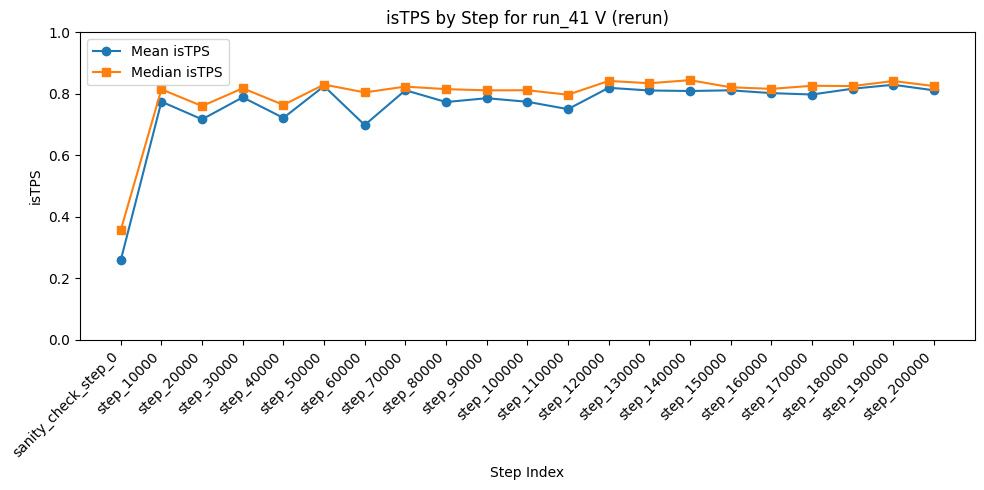

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/stage3_LN_comparison/run_41 V+LN_isTPS_by_step.png


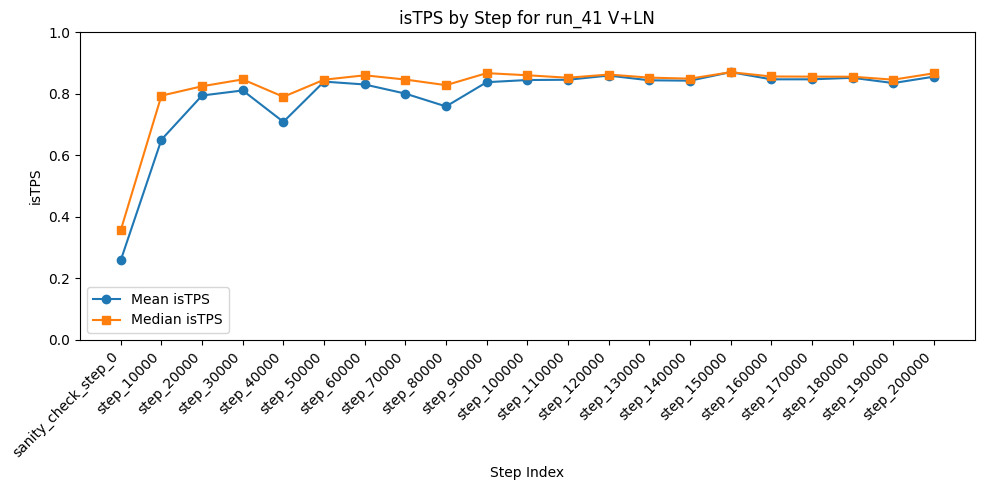

In [10]:
# --- 9. Optional: Per-Run Diagnostic Plot of Mean/Median by Step ---
if not all_isTPS_df.empty:
    for run_name, group in step_stats.groupby("run_name"):
        plt.figure(figsize=(10, 5))
        plt.plot(group["step_index"], group["mean_isTPS"], marker="o", label="Mean isTPS")
        plt.plot(group["step_index"], group["median_isTPS"], marker="s", label="Median isTPS")
        plt.title(f"isTPS by Step for {run_name}")
        plt.xlabel("Step Index")
        plt.ylabel("isTPS")
        plt.ylim(0, 1)
        plt.xticks(group["step_index"], group["step_name"], rotation=45, ha="right")
        plt.legend()
        plt.tight_layout()
        fname = output_dir / f"{run_name}_isTPS_by_step.png"
        plt.savefig(fname, dpi=200, bbox_inches="tight")
        print(f"Saved: {fname}")
        plt.show()